# Review Pipeline Analysis

In [135]:
from pathlib import Path
import json
import re
import sqlite3
import statistics
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import ollama
import numpy as np
import random
from scipy import stats
import plotly.graph_objects as go
REVIEW_OUTPUTS_DIRS = [Path('./review_outputs/qwen2_5_7b'),
                       Path('./review_outputs/qwen3_5_9b'), 
                       Path('./review_outputs/qwen3_8b'), 
                       Path('./review_outputs/llama3_1_8b'), 
                       Path('./review_outputs/phi4_reasoning_14b'), 
                       Path('./review_outputs/apertus'), 
                       Path('./review_outputs/qwen3_14b')]
ICLR_DB_PATH = 'out_general/iclr2019.sqlite'
pd.set_option('display.max_colwidth', 80)


FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

## Load Data

In [136]:
def load_review_files(directories: list[Path]) -> list[dict]:
    data = []
    for directory in directories:
        files = sorted(directory.glob('*.review_pipeline.json'))
        if not files:
            print(f'Warning: no *.review_pipeline.json files found in {directory}')
            continue
        for path in files:
            with path.open('r', encoding='utf-8') as f:
                paper_data = json.load(f)
            paper_data['source_review_dir'] = str(directory)
            paper_data['generated_paper_model'] = directory.name
            paper_data['source_file'] = str(path)
            data.append(paper_data)
        print(f'Loaded {len(files)} paper review files from {directory}')
    if not data:
        raise FileNotFoundError('No *.review_pipeline.json files found in any configured directory')
    print(f'Loaded {len(data)} paper review files in total')
    return data
papers_raw = load_review_files(REVIEW_OUTPUTS_DIRS)

Loaded 200 paper review files from review_outputs/qwen2_5_7b
Loaded 200 paper review files from review_outputs/qwen3_5_9b
Loaded 200 paper review files from review_outputs/qwen3_8b
Loaded 200 paper review files from review_outputs/llama3_1_8b
Loaded 200 paper review files from review_outputs/phi4_reasoning_14b
Loaded 200 paper review files from review_outputs/apertus
Loaded 200 paper review files from review_outputs/qwen3_14b
Loaded 1400 paper review files in total


In [137]:
def word_count(text: str) -> int:
    return len(text.split())
review_rows = []
paper_rows = []
for paper in papers_raw:
    paper_id = paper['paper_id']
    reviewer_ratings = []
    for run in paper['reviews']:
        official = run['official_review']
        rating = official.get('rating')
        reviewer_ratings.append(rating)
        review_rows.append({'paper_id': paper_id, 'reviewer_model': official.get('reviewer_model'), 'title': official.get('title', ''), 'rating': rating, 'review_word_count': word_count(official.get('review', '')), 'title_word_count': word_count(official.get('title', '')), 'num_extracted_strengths': len(official.get('extracted_strengths', [])), 'num_extracted_weaknesses': len(official.get('extracted_weaknesses', [])), 'num_retrieved_chunks': len(run.get('retrieved_chunks', [])), 'official_review_seconds': run.get('timings_seconds', {}).get('official_review')})
    meta = paper.get('meta_review', {})
    paper_rows.append({'paper_id': paper_id, 'area_chair_model': paper.get('area_chair_model'), 'decision': meta.get('decision'), 'mean_rating': statistics.mean(reviewer_ratings) if reviewer_ratings else None, 'std_rating': statistics.pstdev(reviewer_ratings) if len(reviewer_ratings) > 1 else 0.0, 'min_rating': min(reviewer_ratings) if reviewer_ratings else None, 'max_rating': max(reviewer_ratings) if reviewer_ratings else None, 'num_reviewers': len(reviewer_ratings)})
reviews_df = pd.DataFrame(review_rows)
papers_df = pd.DataFrame(paper_rows)
print(f'reviews_df: {len(reviews_df)} rows (one per reviewer per paper)')
print(f'papers_df:  {len(papers_df)} rows (one per paper)')
reviews_df.head()

reviews_df: 4200 rows (one per reviewer per paper)
papers_df:  1400 rows (one per paper)


,paper_id,reviewer_model,title,rating,review_word_count,title_word_count,num_extracted_strengths,num_extracted_weaknesses,num_retrieved_chunks,official_review_seconds
0,idea_002_03,llama3.1:8b,The proposed framework effectively bridges the gap between generative and di...,6,161,30,2,2,3,15.68
1,idea_002_03,qwen3:14b,A promising integration of contrastive learning and adversarial training in ...,6,425,23,2,2,3,28.85
2,idea_002_03,phi4-reasoning:14b,Contrastive Learning with Adversarial Training in Semi-Supervised GANs: A Ba...,6,235,16,2,2,3,30.41
3,idea_002_05,llama3.1:8b,The paper proposes a semi-supervised GAN framework that effectively leverage...,6,233,26,2,2,3,18.87
4,idea_002_05,qwen3:14b,A semi-supervised GAN framework that leverages adversarial representation le...,7,419,27,2,2,3,54.70


## Resolve Generator Model

In [138]:
paper_generator_map = {p['paper_id']: p['generated_paper_model'] for p in papers_raw}

reviews_df['generator_model'] = reviews_df['paper_id'].map(paper_generator_map)
papers_df['generator_model'] = papers_df['paper_id'].map(paper_generator_map)

def _norm(m):
    return re.sub(r'[^a-z0-9]', '', str(m).lower())

reviews_df['is_self_review'] = (
    reviews_df['generator_model'].map(_norm) == reviews_df['reviewer_model'].map(_norm)
)

resolved = reviews_df['generator_model'].notna().sum()
assert resolved > 0, 'generator_model still unresolved'
print(f'Resolved generator model for {resolved} / {len(reviews_df)} review rows')
print(reviews_df.groupby('generator_model')['reviewer_model'].nunique())
print(f"self-review rows: {reviews_df['is_self_review'].sum()}")

Resolved generator model for 4200 / 4200 review rows
generator_model
apertus               3
llama3_1_8b           3
phi4_reasoning_14b    3
qwen2_5_7b            3
qwen3_14b             3
qwen3_5_9b            3
qwen3_8b              3
Name: reviewer_model, dtype: int64
self-review rows: 600


## Rating Distribution

In [139]:
RATING_BANDS = [(1, 2, '1-2 reject'), (3, 4, '3-4 reject'), (5, 5, '5 borderline'), (6, 7, '6-7 accept'), (8, 9, '8-9 clear accept'), (10, 10, '10 exceptional')]

def band_label(rating: float) -> str:
    for (lo, hi, label) in RATING_BANDS:
        if lo <= rating <= hi:
            return label
    return 'unknown'
reviews_df['rating_band'] = reviews_df['rating'].apply(band_label)
print(reviews_df['rating'].describe())
print(reviews_df.groupby('reviewer_model')['rating'].agg(['count', 'mean', 'std', 'min', 'max']))

count    4200.000000
mean        6.211429
std         0.807244
min         1.000000
25%         6.000000
50%         6.000000
75%         7.000000
max         9.000000
Name: rating, dtype: float64
                    count      mean       std  min  max
reviewer_model                                         
llama3.1:8b          1400  6.375000  1.138740    1    9
phi4-reasoning:14b   1400  6.003571  0.620695    1    8
qwen3:14b            1400  6.255714  0.449330    4    7


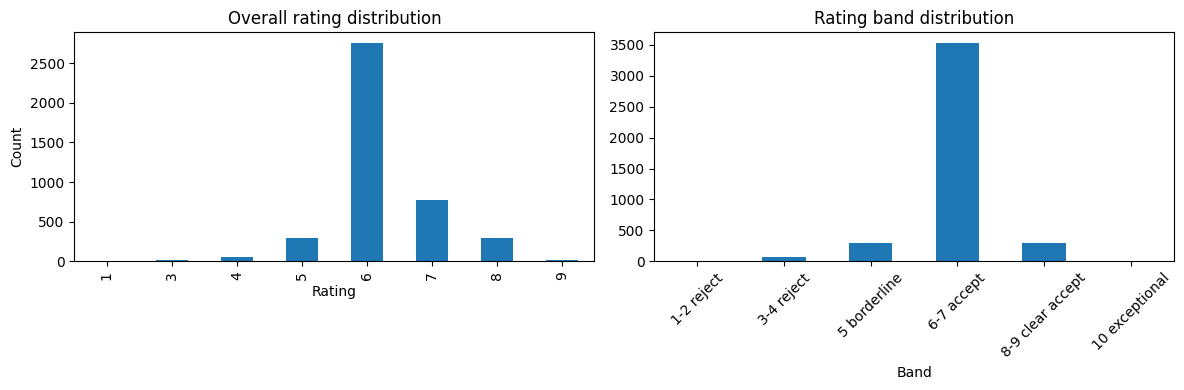

In [140]:
(fig, axes) = plt.subplots(1, 2, figsize=(12, 4))
reviews_df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Overall rating distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
band_order = [b[2] for b in RATING_BANDS]
reviews_df['rating_band'].value_counts().reindex(band_order).fillna(0).plot(kind='bar', ax=axes[1])
axes[1].set_title('Rating band distribution')
axes[1].set_xlabel('Band')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Inter-Reviewer Agreement

count    1400.000000
mean        0.519887
std         0.435174
min         0.000000
25%         0.000000
50%         0.471405
75%         0.816497
max         2.943920
Name: std_rating, dtype: float64
Papers where all reviewers agree within 1 point: 68.9%


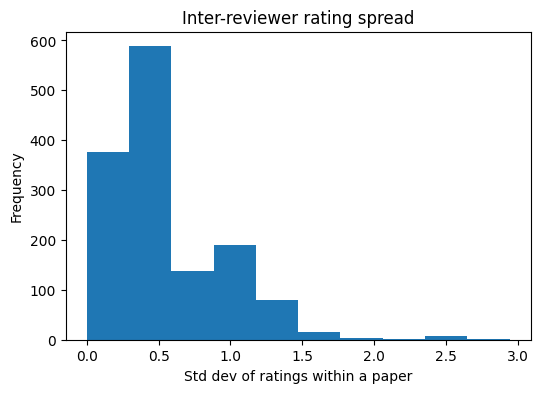

In [141]:
print(papers_df['std_rating'].describe())
within_1_point = (papers_df['max_rating'] - papers_df['min_rating'] <= 1).mean()
print(f'Papers where all reviewers agree within 1 point: {within_1_point:.1%}')
(fig, ax) = plt.subplots(figsize=(6, 4))
papers_df['std_rating'].plot(kind='hist', bins=10, ax=ax)
ax.set_xlabel('Std dev of ratings within a paper')
ax.set_title('Inter-reviewer rating spread')
plt.show()

## Weakness-Category Analysis

category
missing_baselines             0.478810
novelty_concern               0.306905
limited_datasets              0.302857
scalability                   0.279762
generalization                0.184286
hyperparameter_sensitivity    0.174762
no_ablation                   0.170238
theoretical_gap               0.123095
reproducibility               0.007619
Name: count, dtype: float64


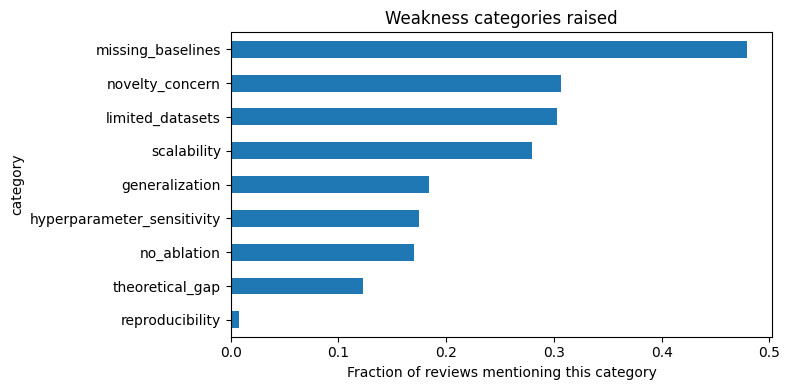

In [142]:
WEAKNESS_KEYWORDS = {'missing_baselines': ['baseline', 'compar'], 'limited_datasets': ['single dataset', 'one dataset', 'limited to', 'only evaluated on'], 'no_ablation': ['ablation'], 'hyperparameter_sensitivity': ['hyperparameter', 'sensitivit'], 'scalability': ['scalab', 'computational overhead', 'computational cost'], 'generalization': ['generaliz'], 'theoretical_gap': ['theoretical', 'assumption'], 'novelty_concern': ['novel', 'prior work', 'related work'], 'reproducibility': ['reproducib', 'implementation detail']}

def categorize_weaknesses(weaknesses: list[str]) -> set[str]:
    text = ' '.join(weaknesses).lower()
    return {cat for (cat, kws) in WEAKNESS_KEYWORDS.items() if any((kw in text for kw in kws))}
category_rows = []
for paper in papers_raw:
    for run in paper['reviews']:
        official = run['official_review']
        cats = categorize_weaknesses(official.get('extracted_weaknesses', []))
        for cat in cats:
            category_rows.append({'paper_id': paper['paper_id'], 'reviewer_model': official.get('reviewer_model'), 'category': cat})
categories_df = pd.DataFrame(category_rows)
n_reviews = len(reviews_df)
freq = categories_df['category'].value_counts() / n_reviews
print(freq)
(fig, ax) = plt.subplots(figsize=(8, 4))
freq.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Fraction of reviews mentioning this category')
ax.set_title('Weakness categories raised')
plt.tight_layout()
plt.show()

In [143]:
category_by_model = categories_df.groupby(['reviewer_model', 'category']).size().unstack(fill_value=0)
category_by_model

category,generalization,hyperparameter_sensitivity,limited_datasets,missing_baselines,no_ablation,novelty_concern,reproducibility,scalability,theoretical_gap
reviewer_model,,,,,,,,,
llama3.1:8b,148,240,76,183,13,91,0,435,141
phi4-reasoning:14b,263,419,267,493,488,58,23,594,258
qwen3:14b,363,75,929,1335,214,1140,9,146,118


## Area Chair Decisions vs. Ratings

In [144]:
print(papers_df['decision'].value_counts())
print(papers_df.groupby('decision')['mean_rating'].describe())
papers_df['is_inconsistent'] = (papers_df['decision'] == 'accept') & (papers_df['mean_rating'] < 5) | (papers_df['decision'] == 'reject') & (papers_df['mean_rating'] >= 6)
print(f"Papers where AC decision looks inconsistent with mean rating: {papers_df['is_inconsistent'].sum()}")

decision
reject    1202
accept     198
Name: count, dtype: int64
           count      mean       std       min       25%       50%       75%  \
decision                                                                       
accept     198.0  6.511785  0.448883  4.666667  6.333333  6.666667  6.666667   
reject    1202.0  6.161952  0.416411  4.000000  6.000000  6.000000  6.333333   

               max  
decision            
accept    7.666667  
reject    7.333333  
Papers where AC decision looks inconsistent with mean rating: 1008


## Sankey visualisation

- Generator to Rating Band to Decision

In [145]:
paper_gen_df = papers_df[['paper_id', 'generator_model', 'decision']].dropna(subset=['generator_model', 'decision'])
paper_level_df = paper_gen_df.merge(papers_df[['paper_id', 'mean_rating']], on='paper_id', how='inner')
paper_level_df['rating_band'] = paper_level_df['mean_rating'].round().apply(band_label)
print(f'Papers with generator, rating, and decision all resolved: {len(paper_level_df)}')
print(paper_level_df['rating_band'].value_counts())

Papers with generator, rating, and decision all resolved: 1400
rating_band
6-7 accept          1336
5 borderline          56
3-4 reject             4
8-9 clear accept       4
Name: count, dtype: int64


In [146]:
band_order = [b[2] for b in RATING_BANDS]
present_bands = [
    b for b in band_order
    if b in paper_level_df["rating_band"].unique()
]

generators = sorted(paper_level_df["generator_model"].unique())
decision_labels = ["accept", "reject"]

all_labels = generators + present_bands + decision_labels
label_to_idx = {label: i for i, label in enumerate(all_labels)}

flow1 = (
    paper_level_df
    .groupby(["generator_model", "rating_band"])
    .size()
    .reset_index(name="count")
)

flow2 = (
    paper_level_df
    .groupby(["rating_band", "decision"])
    .size()
    .reset_index(name="count")
)

sources = []
targets = []
values = []
link_colors = []

for _, row in flow1.iterrows():
    sources.append(label_to_idx[row["generator_model"]])
    targets.append(label_to_idx[row["rating_band"]])
    values.append(row["count"])
    link_colors.append("rgba(120,120,120,0.4)")

for _, row in flow2.iterrows():
    sources.append(label_to_idx[row["rating_band"]])
    targets.append(label_to_idx[row["decision"]])
    values.append(row["count"])

    if row["decision"] == "accept":
        link_colors.append("rgba(84,162,75,0.45)")
    else:
        link_colors.append("rgba(228,87,86,0.35)")

node_colors = (
    ["#4C78A8"] * len(generators)        # generator models
    + ["#F2B701"] * len(present_bands)   # rating bands
    + ["#54A24B", "#E45756"]             # accept / reject
)

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",

            node=dict(
                pad=18,
                thickness=24,
                line=dict(
                    color="black",
                    width=0.7
                ),
                label=all_labels,
                color=node_colors,
            ),

            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors,
            ),
        )
    ]
)

fig.update_layout(
    font=dict(size=15),
    width=1000,
    height=500,
    margin=dict(
        l=30,
        r=30,
        t=20,
        b=20
    ),
)

fig.write_image(
    FIGURES_DIR / "sankey.png",
    width=1800,
    height=900,
    scale=3
)

fig.show()

## Generator self-enhancement and Area Chair self-alignment

In [147]:
valid_gen = reviews_df.dropna(subset=['generator_model'])
print(valid_gen.groupby(['reviewer_model', 'is_self_review'])['rating'].agg(['count', 'mean', 'std']),"\n")
for model in valid_gen['reviewer_model'].unique():
    subset = valid_gen[valid_gen['reviewer_model'] == model]
    self_ratings = subset.loc[subset['is_self_review'], 'rating']
    other_ratings = subset.loc[~subset['is_self_review'], 'rating']
    if len(self_ratings) == 0:
        print(f'{model}: no self-reviewed papers found in this sample -- cannot test.')
        continue
    diff = self_ratings.mean() - other_ratings.mean()
    print(f'{model}: self-review mean={self_ratings.mean():.2f} (n={len(self_ratings)}), other-review mean={other_ratings.mean():.2f} (n={len(other_ratings)}), difference={diff:+.2f}')

                                   count      mean       std
reviewer_model     is_self_review                           
llama3.1:8b        False            1200  6.461667  1.161747
                   True              200  5.855000  0.816891
phi4-reasoning:14b False            1200  6.067500  0.559647
                   True              200  5.620000  0.805509
qwen3:14b          False            1200  6.250000  0.448331
                   True              200  6.290000  0.454901 

llama3.1:8b: self-review mean=5.86 (n=200), other-review mean=6.46 (n=1200), difference=-0.61
qwen3:14b: self-review mean=6.29 (n=200), other-review mean=6.25 (n=1200), difference=+0.04
phi4-reasoning:14b: self-review mean=5.62 (n=200), other-review mean=6.07 (n=1200), difference=-0.45


In [148]:
paper_has_self_reviewer = reviews_df.groupby('paper_id')['is_self_review'].any()
papers_df['has_self_reviewer'] = papers_df['paper_id'].map(paper_has_self_reviewer)
papers_df['accept_binary'] = (papers_df['decision'] == 'accept').astype(int)
print(papers_df.groupby('has_self_reviewer')['accept_binary'].agg(['count', 'mean']))

                   count      mean
has_self_reviewer                 
False                800  0.140000
True                 600  0.143333


In [149]:
for model in valid_gen['reviewer_model'].unique():
    subset = valid_gen[valid_gen['reviewer_model'] == model]
    self_ratings = subset.loc[subset['is_self_review'], 'rating']
    other_ratings = subset.loc[~subset['is_self_review'], 'rating']
    if len(self_ratings) < 2:
        continue
    (t_stat, p_value) = stats.ttest_ind(self_ratings, other_ratings, equal_var=False)
    print(f"{model}:\n diff={self_ratings.mean() - other_ratings.mean():+.2f}, t={t_stat:.2f}, p={p_value:.4f}, {('significant' if p_value < 0.05 else 'not significant')} at α=0.05")

llama3.1:8b:
 diff=-0.61, t=-9.08, p=0.0000, significant at α=0.05
qwen3:14b:
 diff=+0.04, t=1.15, p=0.2497, not significant at α=0.05
phi4-reasoning:14b:
 diff=-0.45, t=-7.56, p=0.0000, significant at α=0.05


### Area Chair self-alignment

In [150]:
self_align_rows = []
for paper in papers_raw:
    ac_model = paper.get('area_chair_model')
    decision = paper.get('meta_review', {}).get('decision')
    ratings_by_model = {}
    for run in paper['reviews']:
        official = run['official_review']
        ratings_by_model[official.get('reviewer_model')] = official.get('rating')
    self_rating = ratings_by_model.get(ac_model)
    other_ratings = [r for (m, r) in ratings_by_model.items() if m != ac_model and r is not None]
    self_align_rows.append({'paper_id': paper['paper_id'], 'ac_model': ac_model, 'decision': decision, 'self_rating': self_rating, 'other_mean_rating': statistics.mean(other_ratings) if other_ratings else None, 'self_minus_other': self_rating - statistics.mean(other_ratings) if self_rating is not None and other_ratings else None})
self_align_df = pd.DataFrame(self_align_rows)
self_align_df['decision_binary'] = (self_align_df['decision'] == 'accept').astype(int)

In [151]:
df = self_align_df.dropna(subset=["self_rating", "other_mean_rating", "decision"]).copy()

df["decision_binary"] = (
    df["decision"]
    .str.strip()
    .str.lower()
    .str.startswith("accept")
    .astype(int)
)

self_rating = df["self_rating"].to_numpy()
other_rating = df["other_mean_rating"].to_numpy()
decision = df["decision_binary"].to_numpy()

# Observed correlations
r_self = np.corrcoef(self_rating, decision)[0, 1]
r_other = np.corrcoef(other_rating, decision)[0, 1]
observed_difference = r_self - r_other

# Bootstrap the difference between correlations
rng = np.random.default_rng(42)
bootstrap_differences = []

for _ in range(10_000):
    indices = rng.integers(0, len(df), len(df))

    boot_self = np.corrcoef(
        self_rating[indices], decision[indices]
    )[0, 1]

    boot_other = np.corrcoef(
        other_rating[indices], decision[indices]
    )[0, 1]

    bootstrap_differences.append(boot_self - boot_other)

bootstrap_differences = np.asarray(bootstrap_differences)

ci_low, ci_high = np.percentile(
    bootstrap_differences, [2.5, 97.5]
)

p_value = 2 * min(
    np.mean(bootstrap_differences <= 0),
    np.mean(bootstrap_differences >= 0)
)

print(f"Correlation between AC's own rating and decision::                 {r_self:.3f}")
print(f"Correlation between other reviewers' mean rating and decision:     {r_other:.3f}")
print(f"Difference:                                                        {observed_difference:+.3f}")
print(f"95% bootstrap CI:                                                 [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Two-sided bootstrap p-value:                                       {p_value:.4f}")

Correlation between AC's own rating and decision::                 0.232
Correlation between other reviewers' mean rating and decision:     0.188
Difference:                                                        +0.044
95% bootstrap CI:                                                 [-0.025, 0.116]
Two-sided bootstrap p-value:                                       0.2062


## Convergence vs Justification (faithfulness check)

In [152]:
EMBED_MODEL = 'nomic-embed-text'
EMBED_SAMPLE_SIZE = None
paper_reviewer_texts = {}
for paper in papers_raw:
    texts = []
    for run in paper['reviews']:
        ws = run['official_review'].get('extracted_weaknesses', []) or []
        joined = ' '.join((w for w in ws if w)).strip()
        if joined:
            texts.append(joined)
    if len(texts) >= 2:
        paper_reviewer_texts[paper['paper_id']] = texts
pids = list(paper_reviewer_texts)
_dec = papers_df.set_index('paper_id')['decision'].to_dict()
if EMBED_SAMPLE_SIZE and len(pids) > EMBED_SAMPLE_SIZE:
    random.seed(42)
    accepts = [p for p in pids if _dec.get(p) == 'accept']
    rejects = [p for p in pids if _dec.get(p) == 'reject']
    pids = accepts + random.sample(rejects, max(0, EMBED_SAMPLE_SIZE - len(accepts)))

def _cos(a, b):
    (a, b) = (np.asarray(a), np.asarray(b))
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))
emb_rows = []
for pid in pids:
    vecs = ollama.embed(model=EMBED_MODEL, input=paper_reviewer_texts[pid])['embeddings']
    sims = [_cos(vecs[a], vecs[b]) for a in range(len(vecs)) for b in range(a + 1, len(vecs))]
    emb_rows.append({'paper_id': pid, 'mean_cosine': sum(sims) / len(sims)})
emb_df = pd.DataFrame(emb_rows).merge(papers_df[['paper_id', 'decision']], on='paper_id', how='left')
emb_df = emb_df.dropna(subset=['decision'])
print(emb_df.groupby('decision')['mean_cosine'].agg(['count', 'mean', 'median', 'std']))

          count      mean    median       std
decision                                     
accept      198  0.678884  0.675384  0.061479
reject     1202  0.673562  0.671292  0.058474


reject: n=1202, mean cosine=0.674
accept: n=198, mean cosine=0.679
Mann-Whitney U (H1: rejected more convergent): p = 0.8032


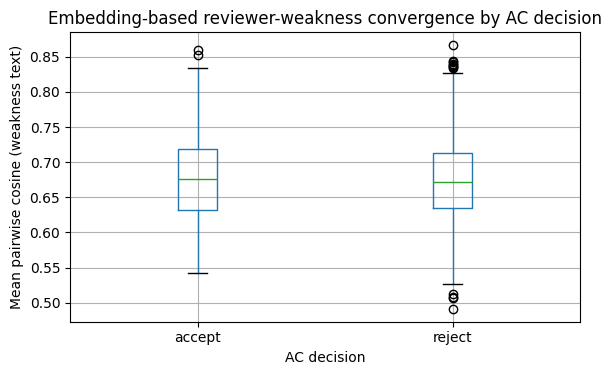

In [153]:
rej = emb_df.loc[emb_df['decision'] == 'reject', 'mean_cosine']
acc = emb_df.loc[emb_df['decision'] == 'accept', 'mean_cosine']
if len(rej) >= 3 and len(acc) >= 3:
    (u, p) = stats.mannwhitneyu(rej, acc, alternative='greater')
    print(f'reject: n={len(rej)}, mean cosine={rej.mean():.3f}')
    print(f'accept: n={len(acc)}, mean cosine={acc.mean():.3f}')
    print(f'Mann-Whitney U (H1: rejected more convergent): p = {p:.4f}')
    (fig, ax) = plt.subplots(figsize=(6, 4))
    emb_df.boxplot(column='mean_cosine', by='decision', ax=ax)
    ax.set_title('Embedding-based reviewer-weakness convergence by AC decision')
    ax.set_xlabel('AC decision')
    ax.set_ylabel('Mean pairwise cosine (weakness text)')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
else:
    print(f'Not enough papers to test (reject n={len(rej)}, accept n={len(acc)}).')

## Comparison Against Real ICLR Reviews

Real ICLR ratings: n=4329, mean=5.44, stdev=1.49
Generated ratings: n=4200, mean=6.21, stdev=0.81


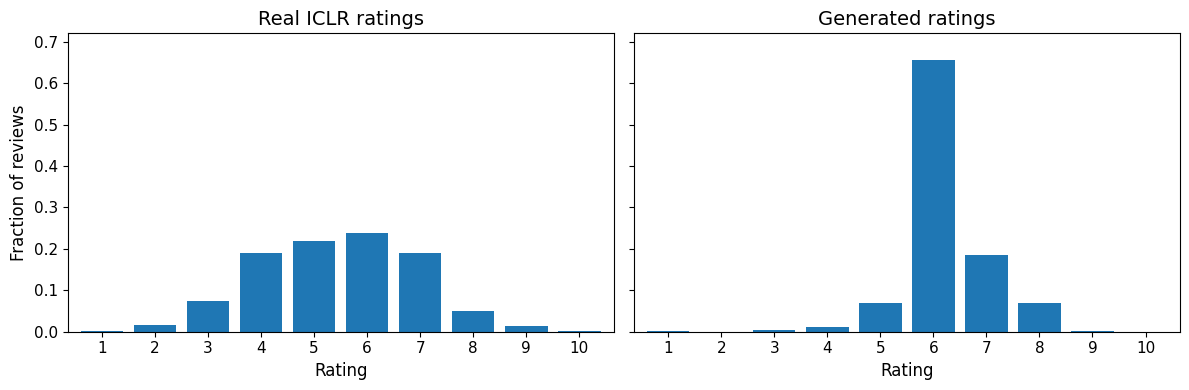

In [154]:
if ICLR_DB_PATH:
    conn = sqlite3.connect(ICLR_DB_PATH)
    real_ratings = [
        r[0]
        for r in conn.execute(
            "SELECT rating FROM reviews WHERE rating IS NOT NULL"
        ).fetchall()
    ]
    conn.close()

    print(
        f"Real ICLR ratings: n={len(real_ratings)}, "
        f"mean={statistics.mean(real_ratings):.2f}, "
        f"stdev={statistics.pstdev(real_ratings):.2f}"
    )
    print(
        f"Generated ratings: n={len(reviews_df)}, "
        f"mean={reviews_df['rating'].mean():.2f}, "
        f"stdev={reviews_df['rating'].std():.2f}"
    )

    # common integer rating axis for both panels
    scale = range(1, 11)

    real_dist = (
        pd.Series(real_ratings)
        .round()
        .astype(int)
        .value_counts(normalize=True)
        .reindex(scale, fill_value=0)
        .sort_index()
    )
    gen_dist = (
        reviews_df["rating"]
        .round()
        .astype(int)
        .value_counts(normalize=True)
        .reindex(scale, fill_value=0)
        .sort_index()
    )

    ymax = max(real_dist.max(), gen_dist.max()) * 1.1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, dist, title in (
        (axes[0], real_dist, "Real ICLR ratings"),
        (axes[1], gen_dist, "Generated ratings"),
    ):
        dist.plot(kind="bar", ax=ax, width=0.8)
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Rating", fontsize=12)
        ax.set_ylim(0, ymax)
        ax.tick_params(axis="x", labelrotation=0, labelsize=11)
        ax.tick_params(axis="y", labelsize=11)

    axes[0].set_ylabel("Fraction of reviews", fontsize=12)

    plt.tight_layout()

    fig.savefig(
        FIGURES_DIR / "rating_distribution_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [155]:
gen_accept_rate = (papers_df['decision'] == 'accept').mean()
print(f"Generated pipeline accept rate: {gen_accept_rate:.1%} ({(papers_df['decision'] == 'accept').sum()} / {papers_df['decision'].notna().sum()})")
if ICLR_DB_PATH:
    try:
        with sqlite3.connect(ICLR_DB_PATH) as conn:
            n_real_decided, n_real_accepted = conn.execute("""
                SELECT COUNT(*) AS n_decided, SUM(CASE WHEN LOWER(TRIM(decision)) LIKE 'accept%' THEN 1 ELSE 0 END) AS n_accepted FROM paper_decisions WHERE decision IS NOT NULL AND TRIM(decision) <> '' """).fetchone()

        n_real_accepted = n_real_accepted or 0

        if n_real_decided > 0:
            real_accept_rate = n_real_accepted / n_real_decided

            print(
                f"Real ICLR accept rate:          "
                f"{real_accept_rate:.1%} "
                f"({n_real_accepted} / {n_real_decided})"
            )
        else:
            print("No ICLR decisions were found in paper_decisions.")

    except Exception as e:
        print(f"Could not read decisions from ICLR DB: {e}")

Generated pipeline accept rate: 14.1% (198 / 1400)
Real ICLR accept rate:          35.4% (502 / 1418)


                            generated  real_ICLR    gap
missing_baselines               0.479      0.613 -0.134
novelty_concern                 0.307      0.434 -0.127
limited_datasets                0.303      0.030  0.273
scalability                     0.280      0.049  0.230
generalization                  0.184      0.154  0.031
hyperparameter_sensitivity      0.175      0.080  0.094
no_ablation                     0.170      0.072  0.099
theoretical_gap                 0.123      0.262 -0.139
reproducibility                 0.008      0.027 -0.020


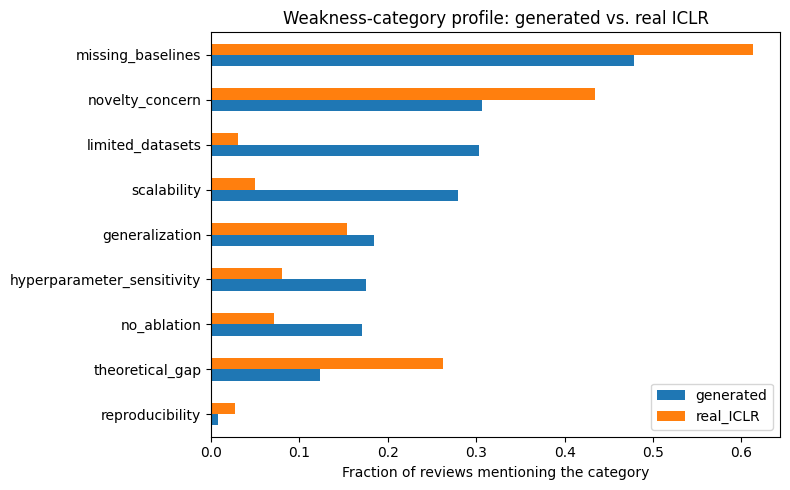

In [156]:
if ICLR_DB_PATH:
    try:
        conn = sqlite3.connect(ICLR_DB_PATH)
        real_texts = [
            r[0]
            for r in conn.execute(
                "SELECT review_text FROM reviews "
                "WHERE review_text IS NOT NULL"
            ).fetchall()
        ]
        conn.close()

        real_cat_counts = Counter()

        for text in real_texts:
            for cat in categorize_weaknesses([text]):
                real_cat_counts[cat] += 1

        real_freq = pd.Series(real_cat_counts) / len(real_texts)
        gen_freq = (
            categories_df["category"].value_counts()
            / len(reviews_df)
        )

        compare = pd.DataFrame({
            "generated": gen_freq,
            "real_ICLR": real_freq
        }).fillna(0)

        compare["gap"] = (
            compare["generated"] - compare["real_ICLR"]
        )

        print(
            compare.sort_values(
                "generated",
                ascending=False
            ).round(3)
        )

        ax = compare[
            ["generated", "real_ICLR"]
        ].sort_values("generated").plot(
            kind="barh",
            figsize=(8, 5)
        )

        ax.set_xlabel("Fraction of reviews mentioning the category")
        ax.set_title("Weakness-category profile: generated vs. real ICLR")

        fig = ax.get_figure()
        fig.tight_layout()

        fig.savefig(
            FIGURES_DIR / "weakness_category_comparison.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

    except Exception as e:
        print(f"Could not run weakness-profile comparison ({e}).")